<a href="https://colab.research.google.com/github/akemitti/Pred-inad-credito/blob/main/notebook04_mistral_estatisticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Aviso:
O notebook foi criado utilizando a GPU, é necessário conectar com a mesma para rodar os códigos.

## Mistral


> **Pré-requisito**: ter o Ollama instalado e o modelo `mistral` baixado.  
> Execute no terminal: `ollama pull mistral` e `ollama serve`.

Se não disponível, a célula gera scores `NaN` e o modelo é excluído do comparativo.

## Instalação das dependências

In [1]:
!pip install ollama

In [2]:
!pip install colab-xterm
%load_ext colabxterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 10.5 MB/s eta 0:00:00


In [3]:
!apt-get update
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!which ollama
!nohup ollama serve >/tmp/ollama.log 2>&1 &
!sleep 5
!ollama pull mistral
!ollama run mistral "Qual é a capital do Brasil?"

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,864 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backpor

## Leitura da base de dados

Em vez de extrair texto dos PDFs, carregamos diretamente o CSV com os textos já extraídos e os scores dos demais modelos. A coluna `texto` equivale ao `Clean_Text` do notebook original.

In [5]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm
import ollama
warnings.filterwarnings('ignore')

# ── Fonte de dados: CSV com textos e scores já calculados ────────────────────
URL_BASE = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_sentimentos_modelos/base_sentimentos_estatisticas_sem_mistral.csv"

try:
    df_base = pd.read_csv("base_sentimentos_estatisticas_sem_mistral.csv")
    print("Base carregada do disco local.")
except FileNotFoundError:
    df_base = pd.read_csv(URL_BASE)
    print("Base carregada do GitHub.")

# Normalizar colunas
df_base.columns = [c.strip().lower() for c in df_base.columns]
if 'unnamed: 0' in df_base.columns:
    df_base = df_base.drop(columns=['unnamed: 0'])

df_base["data"] = pd.to_datetime(df_base["data"], errors="coerce")
df_base["tipo"] = df_base["tipo"].str.lower().str.strip()
df_base = df_base.sort_values("data").reset_index(drop=True)

print(f"Documentos carregados : {len(df_base)}")
print(f"Período               : {df_base['data'].min().date()} a {df_base['data'].max().date()}")
print(f"Colunas               : {list(df_base.columns)}")
df_base[["data", "arquivo", "tipo",
         "score_nltk", "score_textblob", "score_bert", "score_finbert"]].head()

Base carregada do GitHub.
Documentos carregados : 81
Período               : 2019-01-01 a 2025-12-01
Colunas               : ['data', 'texto', 'arquivo', 'tipo', 'score_nltk', 'score_textblob', 'score_bert', 'score_finbert']


,data,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert
0,2019-01-01,201901_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9969,-0.145455,-1.0,0.335325
1,2019-02-01,201902_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9872,-0.400000,-0.5,-0.266386
2,2019-03-01,201903_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9911,-0.320000,-1.0,0.278030
3,2019-04-01,201904_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9934,-0.400000,-1.0,0.407023
4,2019-05-01,201905_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9903,0.000000,-1.0,-0.195990


## LLM Mistral

Utilizamos a LLM Mistral para a análise de sentimento. A escolha se dá pelo seu bom desempenho, compatibilidade com o Google Colab, suporte ao português e por ser um modelo de código aberto que permite reprodutibilidade.

Sites de referência:
- https://www.autonomous.ai/ourblog/llama-vs-mistral-which-performs-better
- https://medium.com/@abonia/running-ollama-in-google-colab-free-tier-545609258453
- https://www.ibm.com/think/topics/mistral-ai

### Funções de análise

 `analisar_documentos` recebe um DataFrame em vez de um dicionário de PDFs — o campo `texto` já contém o texto completo extraído.

In [7]:
def analisar_sentimento(texto_documento):
    SYSTEM_PROMPT = """
    Você é um economista de política monetária no Brasil. Sua tarefa é analisar o sentimento de um documento do Banco Central do Brasil.
    Forneça um score de sentimento de -1.0 (muito negativo/hawkish) a 1.0 (muito positivo/dovish).

    Responda APENAS com um objeto JSON contendo UMA ÚNICA CHAVE, "score".

    Exemplo de resposta:
    {"score": -0.45}
    """

    try:
        response = ollama.chat(
            model='mistral',
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': texto_documento}
            ],
            options={'temperature': 0.2},
            format='json'
        )

        response_text = response['message']['content']
        print(f"Resposta bruta do LLM: {response_text}")

        data = json.loads(response_text)

        if 'score' in data and isinstance(data['score'], (int, float)):
            score = float(data['score'])
            score = max(-1.0, min(1.0, score))
            return score
        else:
            print("Erro: Chave 'score' não encontrada ou não é um número no JSON.")
            return 0.0

    except json.JSONDecodeError:
        print(f"Erro: O LLM não retornou um JSON válido. Resposta: '{response_text}'")
        return 0.0
    except Exception as e:
        print(f"Erro inesperado ao chamar o Ollama: {e}")
        return 0.0


In [8]:
def analisar_documentos_csv(df, coluna_texto="texto", paginas_para_analisar=2):
    """
    Equivalente à função analisar_documentos() do notebook original.
    Recebe um DataFrame com coluna de texto já extraído (sem necessidade de PDFs).

    O parâmetro paginas_para_analisar mantém a compatibilidade lógica:
    como o texto já está concatenado, usamos os últimos N*1500 caracteres
    como aproximação das últimas N páginas (~750 palavras/página).
    """
    CHARS_POR_PAGINA = 1500
    limite_chars = paginas_para_analisar * CHARS_POR_PAGINA

    resultados_parciais = []
    print(f"\n--- Iniciando Análise de Sentimento: Relatório de Estatísticas ---")

    for _, row in df.iterrows():
        nome_arquivo = str(row.get("arquivo", ""))
        data         = row.get("data", None)
        texto_bruto  = str(row.get(coluna_texto, ""))

        if not texto_bruto.strip():
            resultados_parciais.append((nome_arquivo, "Relatório de Estatísticas", data, 0.0, "DOCUMENTO_VAZIO", ""))
            continue

        # Replicar o tratamento original: join + limpeza de espaços + últimas N páginas
        texto_para_analise = ' '.join(texto_bruto.split())   # equivale ao join de páginas + split
        texto_para_analise = texto_para_analise[-limite_chars:]  # últimas N páginas (aprox.)

        if len(texto_para_analise) < 50:
            resultados_parciais.append((nome_arquivo, "Relatório de Estatísticas", data, 0.0, "TEXTO_CURTO", texto_para_analise))
            continue

        score_sentimento = analisar_sentimento(texto_para_analise)
        print(f"Data: {data} | Score Mistral: {score_sentimento:.4f}")

        resultados_parciais.append((nome_arquivo, "Relatório de Estatísticas", data, score_sentimento, "SUCESSO", texto_para_analise))

    return resultados_parciais


### Execução da análise

In [9]:
paginas = 2  # Usar as n últimas páginas (equivalente ao notebook original)

resultados_finais = analisar_documentos_csv(df_base, coluna_texto="texto", paginas_para_analisar=paginas)

print("\n--- Análise Total Concluída ---")

df_resultados = pd.DataFrame(
    resultados_finais,
    columns=["Arquivo", "Tipo", "Data", "Score_Mistral", "Status", "Clean_Text"]
)

df_analise = df_resultados[df_resultados['Status'] == 'SUCESSO'].copy()
df_analise = df_analise.dropna(subset=['Data'])
df_analise = df_analise.sort_values(by="Data")

print(f"Documentos analisados com sucesso: {len(df_analise)}/{len(df_resultados)}")
df_analise[['Data', 'Tipo', 'Score_Mistral', 'Clean_Text']].head()



--- Iniciando Análise de Sentimento: Relatório de Estatísticas ---
Resposta bruta do LLM: {"score": -0.3}
Data: 2019-01-01 00:00:00 | Score Mistral: -0.3000
Resposta bruta do LLM: {"score": -0.6}
Data: 2019-02-01 00:00:00 | Score Mistral: -0.6000
Resposta bruta do LLM: {"score": -0.3}
Data: 2019-03-01 00:00:00 | Score Mistral: -0.3000
Resposta bruta do LLM: {"score": -0.5}
Data: 2019-04-01 00:00:00 | Score Mistral: -0.5000
Resposta bruta do LLM: {"score": -0.5}
Data: 2019-05-01 00:00:00 | Score Mistral: -0.5000
Resposta bruta do LLM: {"score": -0.2}
Data: 2019-06-01 00:00:00 | Score Mistral: -0.2000
Resposta bruta do LLM: {"score": -0.1}
Data: 2019-07-01 00:00:00 | Score Mistral: -0.1000
Resposta bruta do LLM: {"score": -0.2}
Data: 2019-08-01 00:00:00 | Score Mistral: -0.2000
Resposta bruta do LLM: {"score": -0.2}
Data: 2019-09-01 00:00:00 | Score Mistral: -0.2000
Resposta bruta do LLM: {"score": -0.2}
Data: 2019-10-01 00:00:00 | Score Mistral: -0.2000
Resposta bruta do LLM: {"score":

,Data,Tipo,Score_Mistral,Clean_Text
0,2019-01-01,Relatório de Estatísticas,-0.3,"4 p.p. mês e -0,8 p.p. no ano), menor valor de..."
1,2019-02-01,Relatório de Estatísticas,-0.6,"s, cujo resultado compreende as variações nos ..."
2,2019-03-01,Relatório de Estatísticas,-0.3,",6 p.p.) e parcelado (7,4 p.p.). No crédito li..."
3,2019-04-01,Relatório de Estatísticas,-0.5,"u-se em 14,3 p.p. (-0,1 p.p. no mês e -0,1 p.p..."
4,2019-05-01,Relatório de Estatísticas,-0.5,a adquiridos por credores residentes expandiu ...


### Visualização — Score Mistral ao longo do tempo

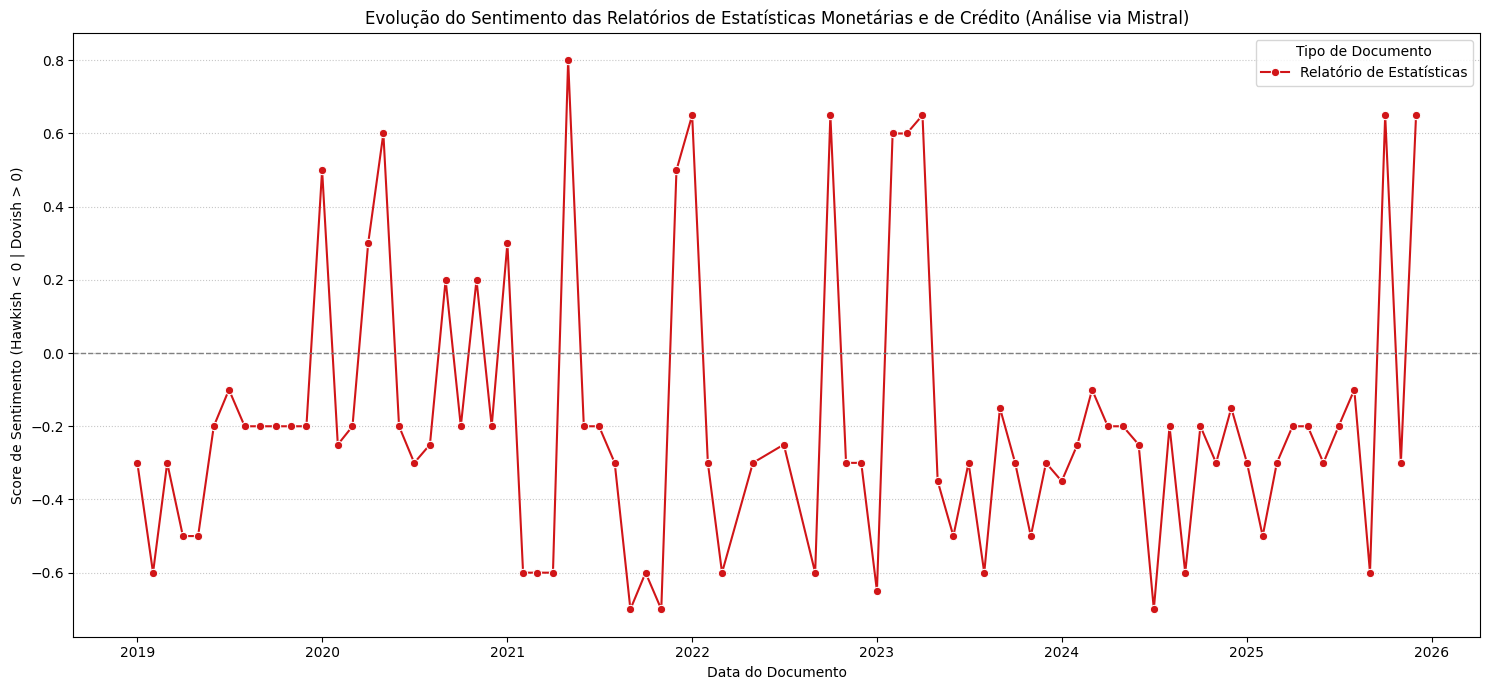

In [10]:
cores = {"Relatório de Estatísticas": "#d11518"}

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=df_analise,
    x="Data",
    y="Score_Mistral",
    hue="Tipo",
    marker="o",
    style="Tipo",
    palette=cores
)

plt.axhline(0, color='grey', linestyle='--', lw=1)
plt.title("Evolução do Sentimento das Relatórios de Estatísticas Monetárias e de Crédito (Análise via Mistral)")
plt.ylabel("Score de Sentimento (Hawkish < 0 | Dovish > 0)")
plt.xlabel("Data do Documento")
plt.legend(title="Tipo de Documento")
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


In [11]:
df_analise.to_csv("/content/sample_data/base_sentimentos_estatisticas_mistral.csv", index=False)